In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

read and show the data

In [7]:
def read_csv(path="data/income.csv"):
    df = pd.read_csv(path)
    return df


df_income = read_csv("data/income.csv")

df_income.head()

,age,workclass,education,marital status,occupation,workinghours,sex,ability to speak english,gave birth this year,income
0,52,self employed,16,Widowed,Transport,50,Male,NaN,NaN,high
1,60,private,20,Divorced,Healthcare/Medical Services,30,Female,NaN,NaN,low
2,64,private,21,Divorced,Management/Business,40,Male,NaN,NaN,low
3,64,private,17,Husband,Transport,40,Male,NaN,NaN,low
4,31,private,15,Husband,Transport,40,Male,NaN,NaN,low


preprocess the data

In [8]:
X = df_income.drop(columns=["income"])
y = df_income["income"]

y = y.map({
    "low": 0,
    "high": 1
})

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


/tmp/ipykernel_13082/1913198495.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


split the data set in 0.8/0.2, specify the models

In [9]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ]
)

train log regression and random forest model

In [10]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [11]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

evaluate function for model

In [16]:

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    # CV
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scoring = {
        "accuracy": "accuracy",
        "auc": "roc_auc",
        "precision_low": make_scorer(precision_score, pos_label=0),
        "recall_low": make_scorer(recall_score, pos_label=0),
        "precision_high": make_scorer(precision_score, pos_label=1),
        "recall_high": make_scorer(recall_score, pos_label=1)
    }

    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # AUC
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    train_auc = roc_auc_score(y_train, y_train_proba)
    test_auc = roc_auc_score(y_test, y_test_proba)

    accuracy_gap = train_accuracy - test_accuracy
    auc_gap = train_auc - test_auc

    # Confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)

    print("=" * 80)
    print(name)
    print("=" * 80)

    # CV results
    print("5-fold cross-validation on training set:")
    print(f"CV accuracy:        {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
    print(f"CV AUC:             {cv_results['test_auc'].mean():.4f} ± {cv_results['test_auc'].std():.4f}")
    print(f"CV precision low:   {cv_results['test_precision_low'].mean():.4f}")
    print(f"CV recall low:      {cv_results['test_recall_low'].mean():.4f}")
    print(f"CV precision high:  {cv_results['test_precision_high'].mean():.4f}")
    print(f"CV recall high:     {cv_results['test_recall_high'].mean():.4f}")

    print("\nOverfitting check using cross-validation:")
    print(f"Train CV accuracy:  {cv_results['train_accuracy'].mean():.4f}")
    print(f"Valid CV accuracy:  {cv_results['test_accuracy'].mean():.4f}")
    print(f"CV accuracy gap:    {(cv_results['train_accuracy'].mean() - cv_results['test_accuracy'].mean()):.4f}")

    print(f"\nTrain CV AUC:       {cv_results['train_auc'].mean():.4f}")
    print(f"Valid CV AUC:       {cv_results['test_auc'].mean():.4f}")
    print(f"CV AUC gap:         {(cv_results['train_auc'].mean() - cv_results['test_auc'].mean()):.4f}")

    # fin eval
    print("\nFinal evaluation after training on full training set:")
    print(f"Train accuracy:     {train_accuracy:.4f}")
    print(f"Test accuracy:      {test_accuracy:.4f}")
    print(f"Accuracy gap:       {accuracy_gap:.4f}")

    print(f"\nTrain AUC:          {train_auc:.4f}")
    print(f"Test AUC:           {test_auc:.4f}")
    print(f"AUC gap:            {auc_gap:.4f}")

    print("\nClassification report on test set:")
    print(classification_report(
        y_test,
        y_test_pred,
        target_names=["low", "high"]
    ))

    print("Confusion matrix on test set:")
    print("Rows = actual class, columns = predicted class")
    print("              Predicted low   Predicted high")
    print(f"Actual low     {cm[0, 0]:>8}        {cm[0, 1]:>8}")
    print(f"Actual high    {cm[1, 0]:>8}        {cm[1, 1]:>8}")

    return {
        "model": name,

        "cv_accuracy": cv_results["test_accuracy"].mean(),
        "cv_auc": cv_results["test_auc"].mean(),
        "cv_accuracy_gap": cv_results["train_accuracy"].mean() - cv_results["test_accuracy"].mean(),
        "cv_auc_gap": cv_results["train_auc"].mean() - cv_results["test_auc"].mean(),

        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "accuracy_gap": accuracy_gap,
        "train_auc": train_auc,
        "test_auc": test_auc,
        "auc_gap": auc_gap
    }

In [17]:
logistic_results = evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_train,
    X_test,
    y_train,
    y_test
)

rf_results = evaluate_model(
    "Random Forest",
    random_forest_model,
    X_train,
    X_test,
    y_train,
    y_test
)

Logistic Regression
5-fold cross-validation on training set:
CV accuracy:        0.7661 ± 0.0101
CV AUC:             0.8540 ± 0.0087
CV precision low:   0.8719
CV recall low:      0.7555
CV precision high:  0.6259
CV recall high:     0.7864

Overfitting check using cross-validation:
Train CV accuracy:  0.7700
Valid CV accuracy:  0.7661
CV accuracy gap:    0.0039

Train CV AUC:       0.8583
Valid CV AUC:       0.8540
CV AUC gap:         0.0043

Final evaluation after training on full training set:
Train accuracy:     0.7694
Test accuracy:      0.7611
Accuracy gap:       0.0083

Train AUC:          0.8578
Test AUC:           0.8497
AUC gap:            0.0082

Classification report on test set:
              precision    recall  f1-score   support

         low       0.87      0.75      0.80      1184
        high       0.62      0.79      0.69       616

    accuracy                           0.76      1800
   macro avg       0.75      0.77      0.75      1800
weighted avg       0.79    

In [18]:
results_df = pd.DataFrame([
    logistic_results,
    rf_results
])

results_df

,model,cv_accuracy,cv_auc,cv_accuracy_gap,cv_auc_gap,train_accuracy,test_accuracy,accuracy_gap,train_auc,test_auc,auc_gap
0,Logistic Regression,0.766111,0.854019,0.003889,0.004267,0.769444,0.761111,0.008333,0.857836,0.849683,0.008153
1,Random Forest,0.768333,0.836688,0.218403,0.162437,0.984444,0.777778,0.206667,0.998822,0.837122,0.161700


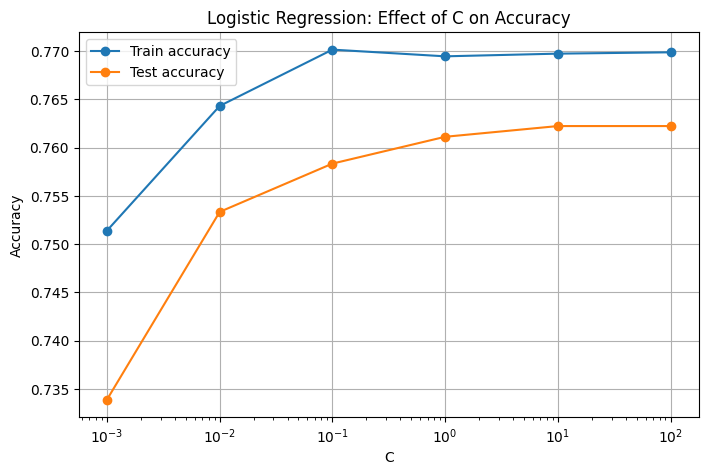

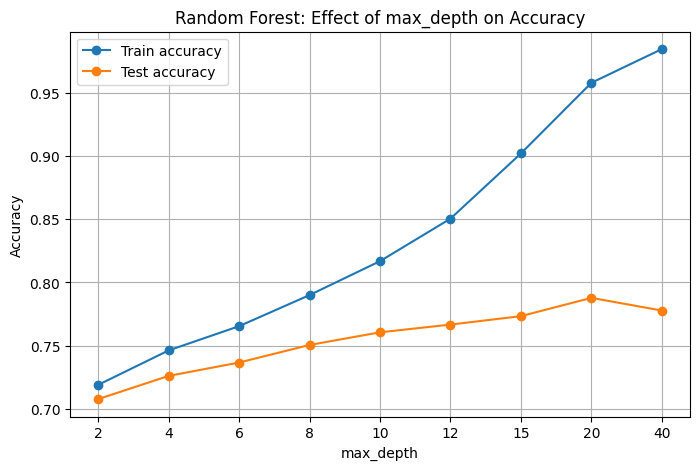

In [19]:

C_values = [0.001, 0.01, 0.1, 1, 10, 100]

log_train_acc = []
log_test_acc = []

for C in C_values:
    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(
                C=C,
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            ))
        ]
    )

    model.fit(X_train, y_train)

    log_train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    log_test_acc.append(accuracy_score(y_test, model.predict(X_test)))


plt.figure(figsize=(8, 5))
plt.plot(C_values, log_train_acc, marker="o", label="Train accuracy")
plt.plot(C_values, log_test_acc, marker="o", label="Test accuracy")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Logistic Regression: Effect of C on Accuracy")
plt.legend()
plt.grid(True)
plt.show()

max_depth_values = [2, 4, 6, 8, 10, 12, 15, 20, 40]
max_depth_labels = ["2", "4", "6", "8", "10", "12", "15", "20", "40"]

rf_train_acc = []
rf_test_acc = []

for max_depth in max_depth_values:
    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", RandomForestClassifier(
                n_estimators=200,
                max_depth=max_depth,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            ))
        ]
    )

    model.fit(X_train, y_train)

    rf_train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    rf_test_acc.append(accuracy_score(y_test, model.predict(X_test)))


plt.figure(figsize=(8, 5))
plt.plot(max_depth_labels, rf_train_acc, marker="o", label="Train accuracy")
plt.plot(max_depth_labels, rf_test_acc, marker="o", label="Test accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Random Forest: Effect of max_depth on Accuracy")
plt.legend()
plt.grid(True)
plt.show()

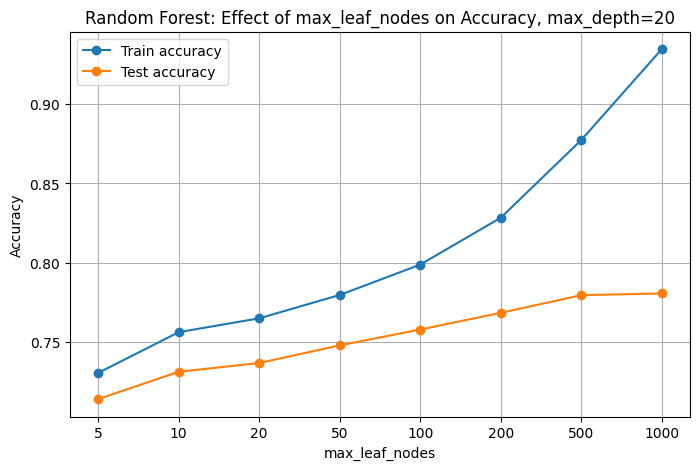

In [20]:

max_leaf_nodes_values = [5, 10, 20, 50, 100, 200, 500, 1000]
max_leaf_nodes_labels = ["5", "10", "20", "50", "100", "200", "500", "1000"]

rf_leaf_nodes_train_acc = []
rf_leaf_nodes_test_acc = []

for max_leaf_nodes in max_leaf_nodes_values:
    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", RandomForestClassifier(
                n_estimators=200,
                max_depth=20,
                max_leaf_nodes=max_leaf_nodes,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            ))
        ]
    )

    model.fit(X_train, y_train)

    rf_leaf_nodes_train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    rf_leaf_nodes_test_acc.append(accuracy_score(y_test, model.predict(X_test)))


plt.figure(figsize=(8, 5))
plt.plot(max_leaf_nodes_labels, rf_leaf_nodes_train_acc, marker="o", label="Train accuracy")
plt.plot(max_leaf_nodes_labels, rf_leaf_nodes_test_acc, marker="o", label="Test accuracy")
plt.xlabel("max_leaf_nodes")
plt.ylabel("Accuracy")
plt.title("Random Forest: Effect of max_leaf_nodes on Accuracy, max_depth=20")
plt.legend()
plt.grid(True)
plt.show()

Optimized models using selected hyperparameters

In [21]:

logistic_model_optimized = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            C=10,
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

random_forest_model_optimized = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            max_leaf_nodes=500,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ]
)


logistic_results_optimized = evaluate_model(
    "Logistic Regression Optimized",
    logistic_model_optimized,
    X_train,
    X_test,
    y_train,
    y_test
)

rf_results_optimized = evaluate_model(
    "Random Forest Optimized",
    random_forest_model_optimized,
    X_train,
    X_test,
    y_train,
    y_test
)

results_df = pd.DataFrame([
    logistic_results,
    logistic_results_optimized,
    rf_results,
    rf_results_optimized
])

results_df

Logistic Regression Optimized
5-fold cross-validation on training set:
CV accuracy:        0.7664 ± 0.0098
CV AUC:             0.8537 ± 0.0085
CV precision low:   0.8718
CV recall low:      0.7562
CV precision high:  0.6263
CV recall high:     0.7860

Overfitting check using cross-validation:
Train CV accuracy:  0.7698
Valid CV accuracy:  0.7664
CV accuracy gap:    0.0034

Train CV AUC:       0.8583
Valid CV AUC:       0.8537
CV AUC gap:         0.0046

Final evaluation after training on full training set:
Train accuracy:     0.7697
Test accuracy:      0.7622
Accuracy gap:       0.0075

Train AUC:          0.8578
Test AUC:           0.8498
AUC gap:            0.0081

Classification report on test set:
              precision    recall  f1-score   support

         low       0.87      0.75      0.81      1184
        high       0.62      0.79      0.69       616

    accuracy                           0.76      1800
   macro avg       0.75      0.77      0.75      1800
weighted avg     

,model,cv_accuracy,cv_auc,cv_accuracy_gap,cv_auc_gap,train_accuracy,test_accuracy,accuracy_gap,train_auc,test_auc,auc_gap
0,Logistic Regression,0.766111,0.854019,0.003889,0.004267,0.769444,0.761111,0.008333,0.857836,0.849683,0.008153
1,Logistic Regression Optimized,0.766389,0.853720,0.003403,0.004575,0.769722,0.762222,0.007500,0.857847,0.849786,0.008060
2,Random Forest,0.768333,0.836688,0.218403,0.162437,0.984444,0.777778,0.206667,0.998822,0.837122,0.161700
3,Random Forest Optimized,0.782778,0.859434,0.113681,0.104216,0.877361,0.779444,0.097917,0.952743,0.855734,0.097009


Shap plots

In [22]:

final_rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            max_leaf_nodes=500,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ]
)

final_rf_model.fit(X_train, y_train)

fitted_preprocessor = final_rf_model.named_steps["preprocessor"]
fitted_classifier = final_rf_model.named_steps["classifier"]

X_test_transformed = fitted_preprocessor.transform(X_test)

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

feature_names = fitted_preprocessor.get_feature_names_out()

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

sample_size = min(300, X_test_transformed_df.shape[0])

X_test_sample = X_test_transformed_df.sample(
    n=sample_size,
    random_state=42
)

explainer = shap.TreeExplainer(fitted_classifier)
shap_values = explainer.shap_values(X_test_sample)

if isinstance(shap_values, list):
    shap_values_high = shap_values[1]
    expected_value_high = explainer.expected_value[1]
else:
    shap_values_high = shap_values[:, :, 1]
    expected_value_high = explainer.expected_value[1]

Global explanation

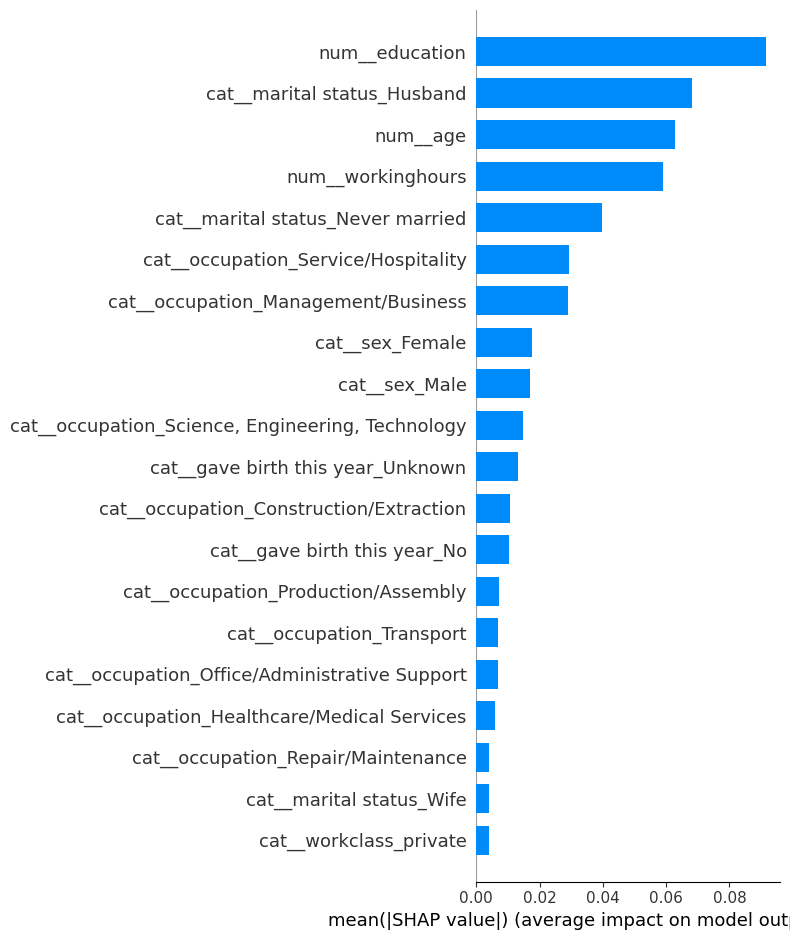

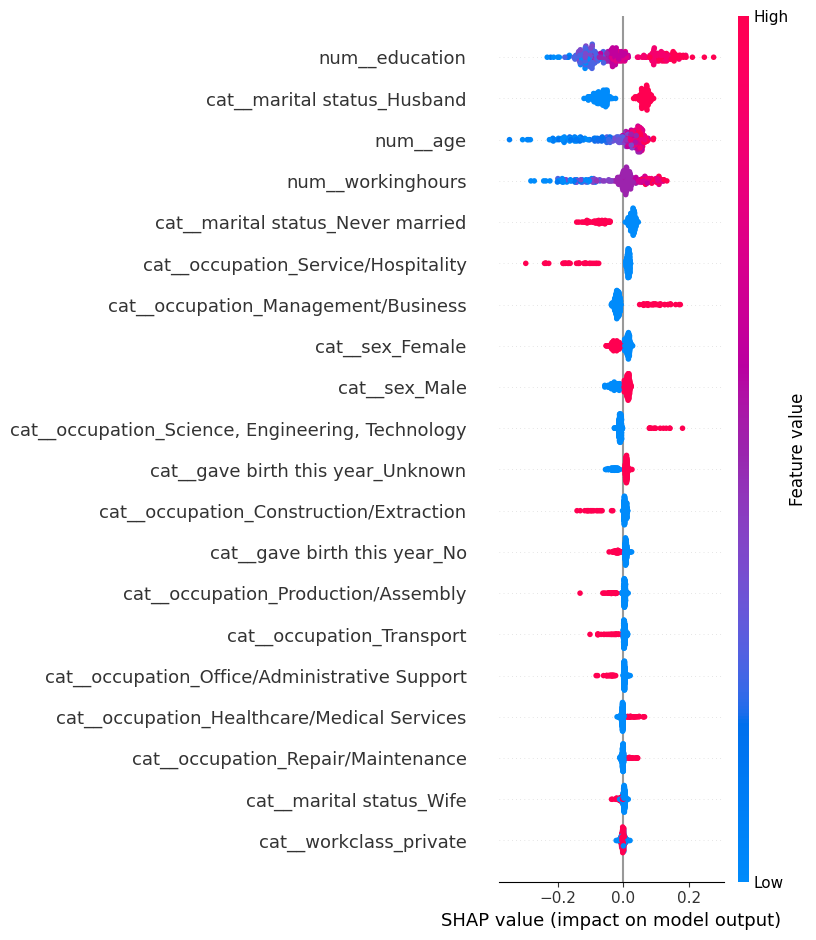

In [100]:

shap.summary_plot(
    shap_values_high,
    X_test_sample,
    plot_type="bar",
    max_display=20
)

shap.summary_plot(
    shap_values_high,
    X_test_sample,
    max_display=20
)

Local explanation

/mnt/storage/projects/DataMining/4/DataMining_assignment4/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/mnt/storage/projects/DataMining/4/DataMining_assignment4/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Prediction explanation 1: predicted LOW income
Predicted probability of high income: 0.0741


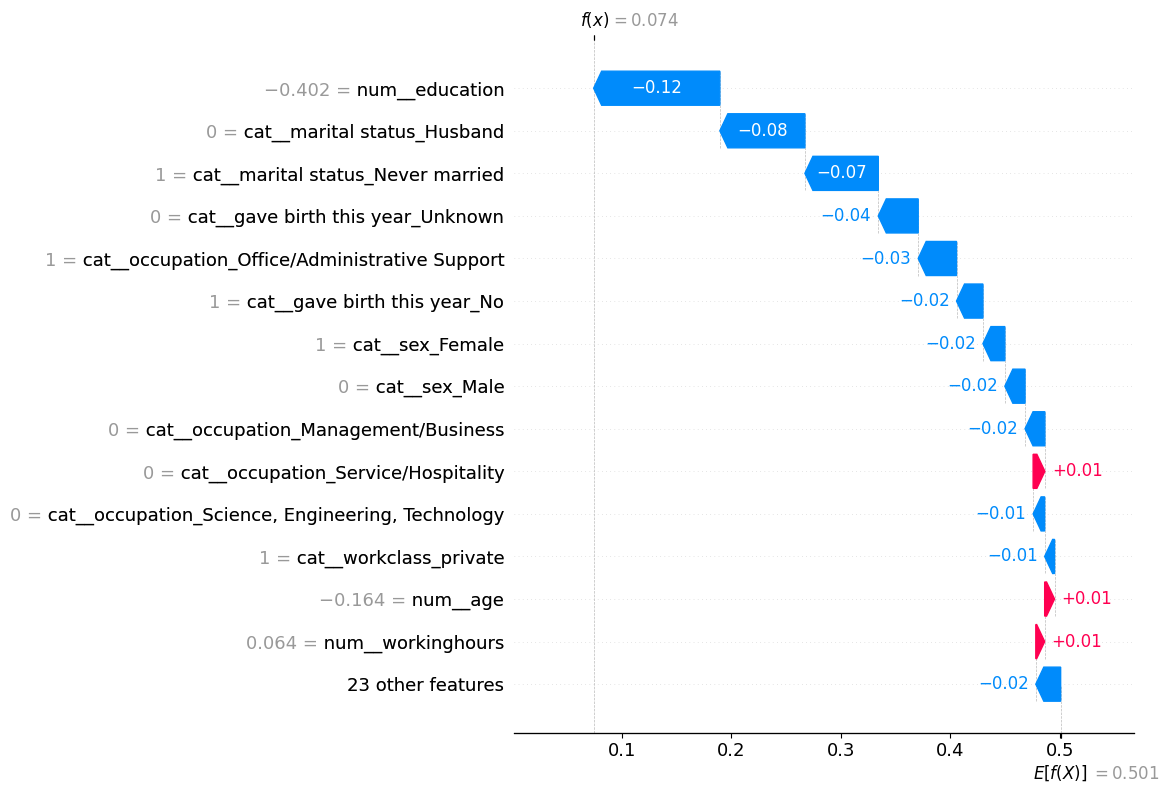

Prediction explanation 2: predicted HIGH income
Predicted probability of high income: 0.6374


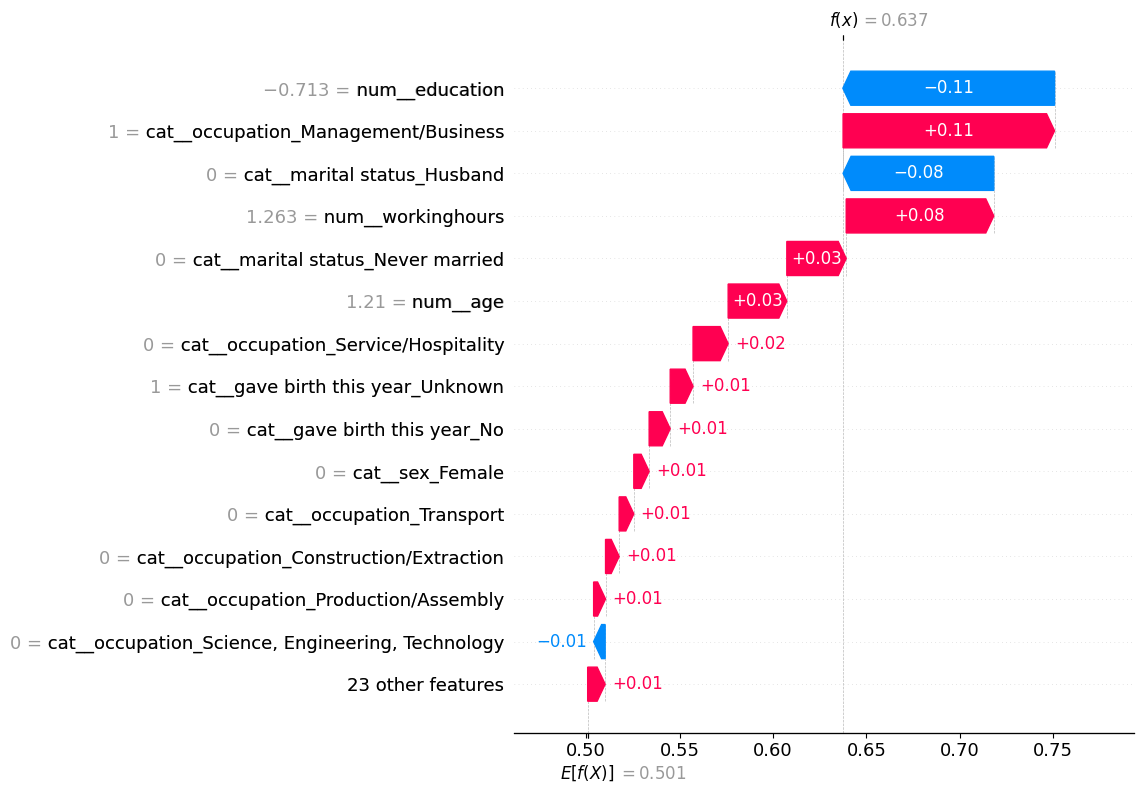

In [101]:

sample_proba = fitted_classifier.predict_proba(X_test_sample)[:, 1]
sample_pred = fitted_classifier.predict(X_test_sample)

low_index = np.where(sample_pred == 0)[0][0]
high_index = np.where(sample_pred == 1)[0][0]

print("Prediction explanation 1: predicted LOW income")
print(f"Predicted probability of high income: {sample_proba[low_index]:.4f}")

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_high[low_index],
        base_values=expected_value_high,
        data=X_test_sample.iloc[low_index],
        feature_names=X_test_sample.columns
    ),
    max_display=15
)

print("Prediction explanation 2: predicted HIGH income")
print(f"Predicted probability of high income: {sample_proba[high_index]:.4f}")

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_high[high_index],
        base_values=expected_value_high,
        data=X_test_sample.iloc[high_index],
        feature_names=X_test_sample.columns
    ),
    max_display=15
)

Predictions template fill

In [102]:
income_test = pd.read_csv("data/income_test.csv")
predictions_template = pd.read_csv("data/predictions_template.csv")

final_rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            max_leaf_nodes=500,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        ))
    ]
)

final_rf_model.fit(X_train, y_train)
test_predictions_numeric = final_rf_model.predict(income_test)
test_predictions_proba = final_rf_model.predict_proba(income_test)[:, 1]

test_predictions_label = pd.Series(test_predictions_numeric).map({
    0: "low",
    1: "high"
})


predictions_template["income"] = test_predictions_label.values
predictions_template.to_csv("data/predictions_template.csv", index=False)
predictions_template.head()

,id,income
0,1,high
1,2,high
2,3,high
3,4,low
4,5,high


In [103]:
pd.read_csv("data/predictions_filled.csv").head()

,id,income
0,1,high
1,2,high
2,3,high
3,4,low
4,5,high


In [104]:
num_predicted_high = (predictions_template["income"] == "high").sum()
num_total = len(predictions_template)

print(f"Predicted high income: {num_predicted_high}")
print(f"Total people: {num_total}")
print(f"Predicted high-income rate: {num_predicted_high / num_total:.2%}")

Predicted high income: 1116
Total people: 2000
Predicted high-income rate: 55.80%


In [110]:

tn = 937
fp = 247
fn = 150
tp = 466

num_predicted_high = (predictions_template["income"] == "high").sum()
num_predicted_low = (predictions_template["income"] == "low").sum()
num_total = len(predictions_template)

test_accuracy = (tp + tn) / (tn + fp + fn + tp)

precision_high = tp / (tp + fp)
missed_high_rate_among_predicted_low = fn / (tn + fn)

estimated_correct_high_predictions = precision_high * num_predicted_high
estimated_missed_high_predictions = missed_high_rate_among_predicted_low * num_predicted_low

estimated_total_actual_high = (
    estimated_correct_high_predictions
    + estimated_missed_high_predictions
)

print(f"Predicted high income: {num_predicted_high}")
print(f"Predicted low income: {num_predicted_low}")
print(f"Total people: {num_total}")

print(f"\nTest accuracy: {test_accuracy:.4f}")
print(f"Precision high: {precision_high:.4f}")
print(f"Missed high rate among predicted low: {missed_high_rate_among_predicted_low:.4f}")

print(f"\nEstimated correctly predicted high-income people: {estimated_correct_high_predictions:.0f}")
print(f"Estimated missed high-income people: {estimated_missed_high_predictions:.0f}")
print(f"Estimated total actual high-income people: {estimated_total_actual_high:.0f}")
print(f"Estimated actual high-income rate: {estimated_total_actual_high / num_total:.2%}")

Predicted high income: 1116
Predicted low income: 884
Total people: 2000

Test accuracy: 0.7794
Precision high: 0.6536
Missed high rate among predicted low: 0.1380

Estimated correctly predicted high-income people: 729
Estimated missed high-income people: 122
Estimated total actual high-income people: 851
Estimated actual high-income rate: 42.57%


Fairness

In [113]:
fairness_df = income_test.copy()
fairness_df["predicted_income"] = predictions_template["income"].values
fairness_df["predicted_high"] = (fairness_df["predicted_income"] == "high").astype(int)

conditional_parity = fairness_df.groupby(["education", "sex"]).agg(
    total_people=("predicted_high", "count"),
    predicted_high_count=("predicted_high", "sum"),
    predicted_high_rate=("predicted_high", "mean")
).reset_index()

conditional_parity_pivot = conditional_parity.pivot(
    index="education",
    columns="sex",
    values="predicted_high_rate"
)

conditional_parity_pivot["gap_male_minus_female"] = (
    conditional_parity_pivot["Male"] - conditional_parity_pivot["Female"]
)

conditional_parity_pivot

sex,Female,Male,gap_male_minus_female
education,,,
1,0.000000,0.428571,0.428571
2,NaN,0.000000,NaN
6,NaN,0.000000,NaN
8,NaN,0.000000,NaN
9,0.000000,0.000000,0.000000
10,NaN,0.000000,NaN
11,0.000000,0.125000,0.125000
12,0.000000,0.400000,0.400000
13,0.000000,0.294118,0.294118
